# MLP: от NumPy к PyTorch

Проект по классификации изображений QuickDraw с реализацией многослойного перцептрона двумя способами: вручную на NumPy и средствами PyTorch.

В работе представлены EDA, препроцессинг, собственная реализация forward/backward propagation, проверка градиентов, обучение и сравнение моделей, эксперимент ReLU vs Tanh, инференс и анализ ошибок.


Для воспроизведения: перед запуском необходимо загрузить файл quickdraw_bitmap.zip в корневую папку /content Google Colab.

In [ ]:
import math
import struct
import time
import urllib.request

from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

In [ ]:
!unzip -q /content/quickdraw_bitmap.zip -d /content/quickdraw_data
!find /content/quickdraw_data -name "00000000.snapshot"

replace /content/quickdraw_data/quickdraw_bitmap/.DS_Store? [y]es, [n]o, [A]ll, [N]one, [r]ename: /content/quickdraw_data/quickdraw_bitmap/5081042506959188152/00000000.shard/00000000.snapshot


## 1. Setup & EDA

In [ ]:
snapshot_files = list(
    Path("/content/quickdraw_data").rglob("00000000.snapshot")
)

if len(snapshot_files) == 0:
    raise FileNotFoundError(
        "00000000.snapshot не найден"
    )

SNAPSHOT = snapshot_files[0]
OUT_DIR = Path("./data/quickdraw_from_snapshot")
MAX_PER_CLASS = 1000

print(SNAPSHOT)
print(SNAPSHOT.exists())


/content/quickdraw_data/quickdraw_bitmap/5081042506959188152/00000000.shard/00000000.snapshot
True


In [ ]:
def iter_tfrecords(path: Path):
    buf = path.read_bytes()
    off, n = 0, len(buf)

    while off + 12 <= n:
        length = struct.unpack_from("<Q", buf, off)[0]
        off += 12

        if off + length + 4 > n:
            break

        yield buf[off : off + length]
        off += length + 4


def parse_image(payload: bytes) -> np.ndarray:
    marker = bytes.fromhex(
        "0804120c1202081c1202081c12020801"
    )

    i = payload.find(marker)

    if i < 0:
        raise ValueError(
            "image TensorProto not found"
        )

    i += len(marker)

    assert payload[i] == 0x22
    i += 1

    L, shift = 0, 0

    while True:
        b = payload[i]
        i += 1

        L |= (b & 0x7F) << shift

        if not (b & 0x80):
            break

        shift += 7

    return np.frombuffer(
        payload[i : i + L],
        dtype=np.uint8
    ).reshape(28, 28).copy()


def parse_label(payload: bytes) -> int:
    i = 0

    while i < len(payload):
        key = payload[i]
        i += 1

        fn, wt = key >> 3, key & 7

        if wt == 0:
            while payload[i] & 0x80:
                i += 1

            i += 1

        elif wt == 2:
            L = payload[i]
            i += 1

            chunk = payload[i : i + L]
            i += L

            if fn == 4 and L == 8:
                return struct.unpack(
                    "<q",
                    chunk
                )[0]

        else:
            break

    raise ValueError(
        "label not found"
    )

In [ ]:
cats_path = Path("categories.txt")

if not cats_path.exists():
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/googlecreativelab/"
        "quickdraw-dataset/master/categories.txt",
        cats_path
    )

snapshot_class_names = [
    line.strip()
    for line in cats_path.read_text().splitlines()
    if line.strip()
]

buckets = defaultdict(list)
it = iter_tfrecords(SNAPSHOT)
n = 0

while True:
    try:
        img_rec = next(it)
        lab_rec = next(it)

    except StopIteration:
        break

    label = parse_label(lab_rec)

    if len(buckets[label]) >= MAX_PER_CLASS:
        continue

    buckets[label].append(
        parse_image(img_rec)
    )

    n += 1

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

for label, imgs in buckets.items():
    arr = np.stack(
        imgs,
        axis=0
    ).reshape(
        len(imgs),
        784
    )

    np.save(
        OUT_DIR / f"{snapshot_class_names[label]}.npy",
        arr.astype(np.uint8)
    )

print(
    "Классов:",
    len(buckets)
)

print(
    "Изображений:",
    n
)

Классов: 345
Изображений: 345000


In [ ]:
def load_quickdraw_npys(data_dir: Path, classes=None, max_per_class=None):
    """
    Загружает per-class .npy файлы из data_dir и возвращает объединённые X, y и список имён классов.

    Args:
        data_dir (Path): директория с файлами формата CLASS.npy.
        classes (list[str] | None): опциональный список имён файлов для загрузки.
            Если None — загружаются все найденные .npy в каталоге.
        max_per_class (int | None): если задано, берётся не более этого числа примеров из каждого файла.

    Returns:
        X (np.ndarray, dtype=uint8): объединённый массив изображений формы (N_total, H, W).
        y (np.ndarray, dtype=int64): вектор меток длины N_total, метки - индексы файлов в порядке files.
        class_names (list[str]): список имён классов (без .npy), порядок соответствует меткам.


    """
    data_dir = Path(data_dir)
    files = sorted([p for p in data_dir.glob('*.npy')])
    if classes is not None:
        files = [data_dir/f'{c}.npy' for c in classes]
    X_list = []
    y_list = []
    class_names = []
    # Для каждого файла загружаем массив
    for idx, f in enumerate(files):
        if not f.exists():
            print('Warning: missing', f)
            continue
        # Загружаем массив
        arr = np.load(f)
        # Преобразуем в (N,H,W)
        N, D = arr.shape
        s = int(math.isqrt(D))
        arr = arr.reshape((N, s, s))
        n = arr.shape[0]
        # Max_per_class обрезает количество
        if max_per_class is not None:
            arr = arr[:max_per_class]
            n = arr.shape[0]
        X_list.append(arr.astype(np.uint8))
        y_list.append(np.full(n, idx, dtype=np.int64))
        class_names.append(f.stem)
    if len(X_list) == 0:
        return np.zeros((0,32,32), dtype=np.uint8), np.array([], dtype=np.int64), []
    X = np.concatenate(X_list, axis=0)
    y = np.concatenate(y_list, axis=0)
    perm = np.random.permutation(len(X))
    return X[perm], y[perm], class_names


In [ ]:
files = sorted(
    OUT_DIR.glob("*.npy")
)

print(
    "Количество файлов:",
    len(files)
)

for f in files:
    arr = np.load(f)

    print(
        f.name,
        "shape =", arr.shape,
        "dtype =", arr.dtype,
        "min =", arr.min(),
        "max =", arr.max()
    )

Количество файлов: 345
The Eiffel Tower.npy shape = (1000, 784) dtype = uint8 min = 0 max = 255
The Great Wall of China.npy shape = (1000, 784) dtype = uint8 min = 0 max = 255
The Mona Lisa.npy shape = (1000, 784) dtype = uint8 min = 0 max = 255
aircraft carrier.npy shape = (1000, 784) dtype = uint8 min = 0 max = 255
airplane.npy shape = (1000, 784) dtype = uint8 min = 0 max = 255
alarm clock.npy shape = (1000, 784) dtype = uint8 min = 0 max = 255
ambulance.npy shape = (1000, 784) dtype = uint8 min = 0 max = 255
angel.npy shape = (1000, 784) dtype = uint8 min = 0 max = 255
animal migration.npy shape = (1000, 784) dtype = uint8 min = 0 max = 255
ant.npy shape = (1000, 784) dtype = uint8 min = 0 max = 255
anvil.npy shape = (1000, 784) dtype = uint8 min = 0 max = 255
apple.npy shape = (1000, 784) dtype = uint8 min = 0 max = 255
arm.npy shape = (1000, 784) dtype = uint8 min = 0 max = 255
asparagus.npy shape = (1000, 784) dtype = uint8 min = 0 max = 255
axe.npy shape = (1000, 784) dtype = u

In [ ]:
X, y, class_names = load_quickdraw_npys(
    OUT_DIR,
    max_per_class=1000
)

print(
    "X:",
    X.shape,
    X.dtype,
    X.min(),
    X.max()
)

print(
    "y:",
    y.shape,
    y.dtype
)

print(
    "Уникальных меток:",
    len(np.unique(y))
)

print(
    "class_names:",
    len(class_names)
)

print(
    "Число меток совпадает:",
    len(np.unique(y)) == len(class_names)
)

X: (345000, 28, 28) uint8 0 255
y: (345000,) int64
Уникальных меток: 345
class_names: 345
Число меток совпадает: True


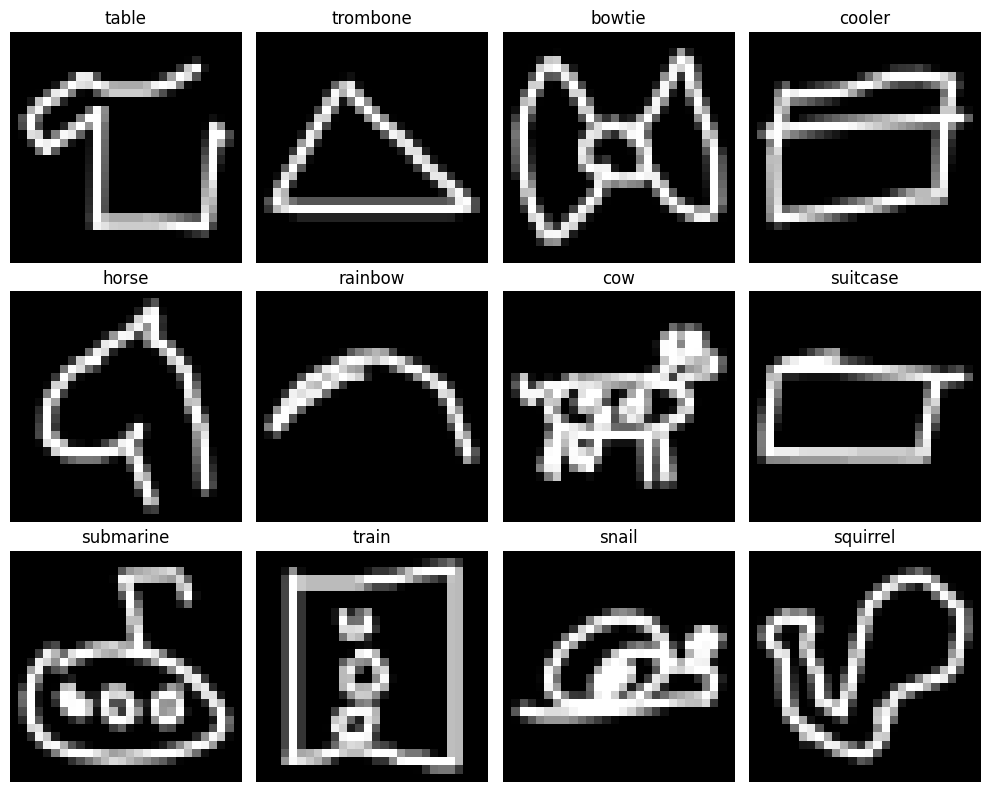

In [ ]:
plt.figure(
    figsize=(10, 8)
)

for i in range(12):
    plt.subplot(
        3,
        4,
        i + 1
    )

    plt.imshow(
        X[i],
        cmap="gray"
    )

    plt.title(
        class_names[y[i]]
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

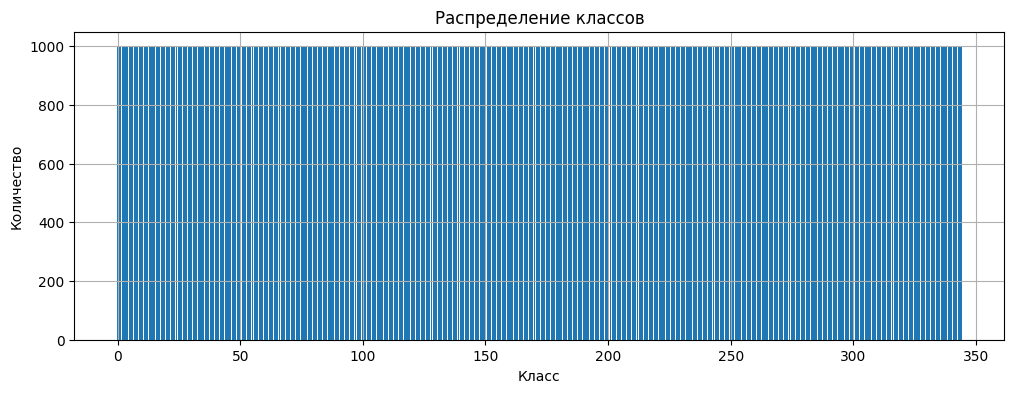

In [ ]:
counts = np.bincount(y)

plt.figure(
    figsize=(12, 4)
)

plt.bar(
    range(len(counts)),
    counts
)

plt.xlabel("Класс")
plt.ylabel("Количество")
plt.title("Распределение классов")
plt.grid(True)

plt.show()

## 2. Препроцессинг

In [ ]:
resize = transforms.Resize(
    (32, 32)
)


def preprocess_images(X):
    X_new = []

    for image in X:
        image = torch.tensor(
            image,
            dtype=torch.float32
        ).unsqueeze(0)

        image = resize(image)

        image = (
            image / 255.0
        )

        X_new.append(
            image.squeeze(0).numpy()
        )

    return np.array(
        X_new,
        dtype=np.float32
    )

In [ ]:
X_processed = preprocess_images(X)

print(
    "До:",
    X.shape,
    X.dtype,
    X.min(),
    X.max()
)

print(
    "После:",
    X_processed.shape,
    X_processed.dtype,
    X_processed.min(),
    X_processed.max()
)

До: (345000, 28, 28) uint8 0 255
После: (345000, 32, 32) float32 0.0 1.0


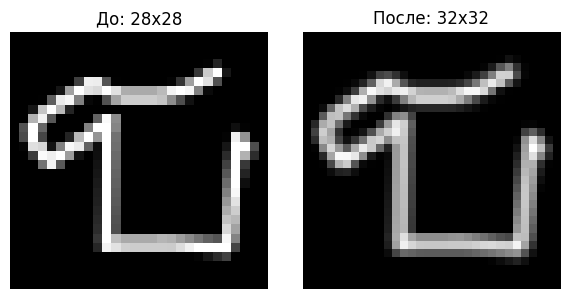

Метка до/после: 305 table


In [ ]:
plt.figure(
    figsize=(6, 3)
)

plt.subplot(
    1,
    2,
    1
)

plt.imshow(
    X[0],
    cmap="gray"
)

plt.title("До: 28x28")
plt.axis("off")


plt.subplot(
    1,
    2,
    2
)

plt.imshow(
    X_processed[0],
    cmap="gray"
)

plt.title("После: 32x32")
plt.axis("off")

plt.tight_layout()
plt.show()

print(
    "Метка до/после:",
    y[0],
    class_names[y[0]]
)

In [ ]:
np.random.seed(SEED)

perm = np.random.permutation(
    len(X_processed)
)

train_end = int(
    0.7 * len(X_processed)
)

val_end = int(
    0.85 * len(X_processed)
)

X_train = X_processed[
    perm[:train_end]
]

y_train = y[
    perm[:train_end]
]

X_val = X_processed[
    perm[train_end:val_end]
]

y_val = y[
    perm[train_end:val_end]
]

X_test = X_processed[
    perm[val_end:]
]

y_test = y[
    perm[val_end:]
]

print(
    "Train:",
    X_train.shape,
    y_train.shape
)

print(
    "Val:",
    X_val.shape,
    y_val.shape
)

print(
    "Test:",
    X_test.shape,
    y_test.shape
)

Train: (241499, 32, 32) (241499,)
Val: (51751, 32, 32) (51751,)
Test: (51750, 32, 32) (51750,)


## 3. Реализация MLP на NumPy

In [ ]:
class NumpyMLP:
    def __init__(
        self,
        layer_sizes,
        activation="relu",
        init_method="xavier"
    ):
        self.layer_sizes = layer_sizes
        self.activation = activation
        self.init_method = init_method

        self.W = []
        self.b = []

        self.Z_list = []
        self.A_list = []

        self.dW_list = []
        self.db_list = []

        self.mW = []
        self.vW = []
        self.mb = []
        self.vb = []

        self.t = 0

        for i in range(
            len(layer_sizes) - 1
        ):
            in_dim = layer_sizes[i]
            out_dim = layer_sizes[i + 1]

            if init_method == "xavier":
                W = np.random.randn(
                    in_dim,
                    out_dim
                ) * np.sqrt(
                    2 / (
                        in_dim + out_dim
                    )
                )

            elif init_method == "he":
                W = np.random.randn(
                    in_dim,
                    out_dim
                ) * np.sqrt(
                    2 / in_dim
                )

            else:
                raise ValueError(
                    init_method
                )

            b = np.zeros(
                (1, out_dim)
            )

            self.W.append(
                W.astype(np.float32)
            )

            self.b.append(
                b.astype(np.float32)
            )

            self.mW.append(
                np.zeros_like(
                    self.W[-1]
                )
            )

            self.vW.append(
                np.zeros_like(
                    self.W[-1]
                )
            )

            self.mb.append(
                np.zeros_like(
                    self.b[-1]
                )
            )

            self.vb.append(
                np.zeros_like(
                    self.b[-1]
                )
            )


    def _activate(self, Z):
        if self.activation == "relu":
            return np.maximum(
                0,
                Z
            )

        elif self.activation == "tanh":
            return np.tanh(Z)

        else:
            raise ValueError(
                self.activation
            )


    def _dactivate(self, Z):
        if self.activation == "relu":
            return (
                Z > 0
            ).astype(float)

        elif self.activation == "tanh":
            return (
                1
                - np.tanh(Z) ** 2
            )


    def forward(self, X):
        self.Z_list = []
        self.A_list = []

        A = X

        self.A_list.append(A)

        for i in range(
            len(self.W)
        ):
            Z = (
                A.dot(
                    self.W[i]
                )
                + self.b[i]
            )

            self.Z_list.append(Z)

            if i < len(self.W) - 1:
                A = self._activate(Z)

            else:
                A = Z

            self.A_list.append(A)

        return A


    def softmax_cross_entropy(
        self,
        logits,
        y_true
    ):
        logits = (
            logits
            - np.max(
                logits,
                axis=1,
                keepdims=True
            )
        )

        exp_logits = np.exp(
            logits
        )

        probs = (
            exp_logits
            / np.sum(
                exp_logits,
                axis=1,
                keepdims=True
            )
        )

        self.probs = probs

        loss = -np.mean(
            np.log(
                probs[
                    np.arange(
                        len(y_true)
                    ),
                    y_true
                ]
                + 1e-12
            )
        )

        return loss


    def backward(self, y_true):
        m = len(y_true)

        delta = (
            self.probs.copy()
        )

        delta[
            np.arange(m),
            y_true
        ] -= 1

        delta = (
            delta / m
        )

        self.dW_list = []
        self.db_list = []

        for i in range(
            len(self.W) - 1,
            -1,
            -1
        ):
            A_prev = (
                self.A_list[i]
            )

            dW = (
                A_prev.T.dot(
                    delta
                )
            )

            db = np.sum(
                delta,
                axis=0,
                keepdims=True
            )

            self.dW_list.insert(
                0,
                dW
            )

            self.db_list.insert(
                0,
                db
            )

            if i > 0:
                delta = (
                    delta.dot(
                        self.W[i].T
                    )
                    * self._dactivate(
                        self.Z_list[
                            i - 1
                        ]
                    )
                )


    def step_sgd(self, lr):
        for i in range(
            len(self.W)
        ):
            self.W[i] -= (
                lr
                * self.dW_list[i]
            )

            self.b[i] -= (
                lr
                * self.db_list[i]
            )


    def step_adam(
        self,
        lr,
        beta1=0.9,
        beta2=0.999,
        eps=1e-8
    ):
        self.t += 1

        for i in range(
            len(self.W)
        ):
            self.mW[i] = (
                beta1
                * self.mW[i]
                + (
                    1 - beta1
                )
                * self.dW_list[i]
            )

            self.vW[i] = (
                beta2
                * self.vW[i]
                + (
                    1 - beta2
                )
                * self.dW_list[i] ** 2
            )

            self.mb[i] = (
                beta1
                * self.mb[i]
                + (
                    1 - beta1
                )
                * self.db_list[i]
            )

            self.vb[i] = (
                beta2
                * self.vb[i]
                + (
                    1 - beta2
                )
                * self.db_list[i] ** 2
            )

            mW_hat = (
                self.mW[i]
                / (
                    1
                    - beta1 ** self.t
                )
            )

            vW_hat = (
                self.vW[i]
                / (
                    1
                    - beta2 ** self.t
                )
            )

            mb_hat = (
                self.mb[i]
                / (
                    1
                    - beta1 ** self.t
                )
            )

            vb_hat = (
                self.vb[i]
                / (
                    1
                    - beta2 ** self.t
                )
            )

            self.W[i] -= (
                lr
                * mW_hat
                / (
                    np.sqrt(
                        vW_hat
                    )
                    + eps
                )
            )

            self.b[i] -= (
                lr
                * mb_hat
                / (
                    np.sqrt(
                        vb_hat
                    )
                    + eps
                )
            )

In [ ]:
def numeric_grad_check(model, X, y, eps=1e-3):
    logits = model.forward(X)
    model.softmax_cross_entropy(logits, y)
    model.backward(y)

    grad_matrix = model.dW_list[0]

    nonzero = np.argwhere(
        np.abs(grad_matrix) > 1e-8
    )

    if len(nonzero) == 0:
        print("Не найден ненулевой градиент")
        return

    i, j = nonzero[0]

    analytic_grad = grad_matrix[i, j]

    original_value = model.W[0][i, j]

    model.W[0][i, j] = original_value + eps
    logits_plus = model.forward(X)
    loss_plus = model.softmax_cross_entropy(
        logits_plus,
        y
    )

    model.W[0][i, j] = original_value - eps
    logits_minus = model.forward(X)
    loss_minus = model.softmax_cross_entropy(
        logits_minus,
        y
    )

    numeric_grad = (
        loss_plus - loss_minus
    ) / (2 * eps)

    model.W[0][i, j] = original_value

    print("Проверяем вес:", i, j)
    print("Analytic gradient:", analytic_grad)
    print("Numeric gradient:", numeric_grad)
    print(
        "Difference:",
        abs(
            analytic_grad
            - numeric_grad
        )
    )

In [ ]:
Path("./models").mkdir(
    exist_ok=True
)


def save_numpy_model(
    model,
    path
):
    data = {
        "layer_sizes":
            np.array(
                model.layer_sizes
            ),

        "activation":
            np.array(
                model.activation
            ),

        "init_method":
            np.array(
                model.init_method
            )
    }

    for i in range(
        len(model.W)
    ):
        data[f"W{i}"] = (
            model.W[i]
        )

        data[f"b{i}"] = (
            model.b[i]
        )

    np.savez(
        path,
        **data
    )


def load_numpy_model(
    path
):
    data = np.load(
        path,
        allow_pickle=True
    )

    layer_sizes = (
        data["layer_sizes"]
        .tolist()
    )

    activation = str(
        data["activation"]
        .item()
    )

    init_method = str(
        data["init_method"]
        .item()
    )

    model = NumpyMLP(
        layer_sizes,
        activation=activation,
        init_method=init_method
    )

    for i in range(
        len(model.W)
    ):
        model.W[i] = (
            data[f"W{i}"]
        )

        model.b[i] = (
            data[f"b{i}"]
        )

    return model

In [ ]:
def evaluate_numpy(
    model,
    X,
    y
):
    logits = model.forward(
        X
    )

    loss = (
        model
        .softmax_cross_entropy(
            logits,
            y
        )
    )

    predicted = np.argmax(
        logits,
        axis=1
    )

    accuracy = np.mean(
        predicted == y
    )

    return (
        loss,
        accuracy
    )

In [ ]:
def train_numpy(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=60,
    batch_size=128,
    lr=0.001
):
    train_losses = []
    val_losses = []
    val_accuracies = []
    epoch_times = []

    best_val_acc = 0
    best_epoch = 0
    best_W = None
    best_b = None

    for epoch in range(
        epochs
    ):
        start_time = (
            time.time()
        )

        perm = np.random.permutation(
            len(X_train)
        )

        running_loss = 0
        batches = 0

        for start in range(
            0,
            len(X_train),
            batch_size
        ):
            idx = perm[
                start:
                start + batch_size
            ]

            X_batch = (
                X_train[idx]
            )

            y_batch = (
                y_train[idx]
            )

            logits = model.forward(
                X_batch
            )

            loss = (
                model
                .softmax_cross_entropy(
                    logits,
                    y_batch
                )
            )

            model.backward(
                y_batch
            )

            model.step_adam(
                lr
            )

            running_loss += loss
            batches += 1

        train_loss = (
            running_loss
            / batches
        )

        val_loss, val_acc = (
            evaluate_numpy(
                model,
                X_val,
                y_val
            )
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1

            best_W = [
                W.copy()
                for W in model.W
            ]

            best_b = [
                b.copy()
                for b in model.b
            ]

        epoch_time = (
            time.time()
            - start_time
        )

        train_losses.append(
            train_loss
        )

        val_losses.append(
            val_loss
        )

        val_accuracies.append(
            val_acc
        )

        epoch_times.append(
            epoch_time
        )

        print(
            f"Epoch {epoch + 1}/{epochs}: "
            f"val_loss={val_loss:.4f}, "
            f"val_acc={val_acc:.4f}, "
            f"time={epoch_time:.2f}s"
        )

    model.W = best_W
    model.b = best_b

    return (
        train_losses,
        val_losses,
        val_accuracies,
        epoch_times,
        best_epoch,
        best_val_acc
    )

In [ ]:
X_train_np = X_train.reshape(
    len(X_train),
    -1
)

X_val_np = X_val.reshape(
    len(X_val),
    -1
)

X_test_np = X_test.reshape(
    len(X_test),
    -1
)

layer_sizes = [
    32 * 32,
    256,
    128,
    len(class_names)
]

np.random.seed(SEED)

numpy_model = NumpyMLP(
    layer_sizes,
    activation="relu",
    init_method="xavier"
)

numpy_train_loss, numpy_val_loss, numpy_val_acc_history, numpy_epoch_time, numpy_best_epoch, numpy_best_val_acc = train_numpy(
    numpy_model,
    X_train_np,
    y_train,
    X_val_np,
    y_val,
    epochs=60,
    batch_size=128,
    lr=0.001
)

save_numpy_model(
    numpy_model,
    "./models/best_numpy_model.npz"
)

numpy_model_loaded = (
    load_numpy_model(
        "./models/best_numpy_model.npz"
    )
)

numpy_val_loss_best, numpy_val_acc = evaluate_numpy(
    numpy_model_loaded,
    X_val_np,
    y_val
)

numpy_test_loss, numpy_test_acc = evaluate_numpy(
    numpy_model_loaded,
    X_test_np,
    y_test
)

print(
    "Best epoch:",
    numpy_best_epoch
)

print(
    "Val accuracy:",
    numpy_val_acc
)

print(
    "Test accuracy:",
    numpy_test_acc
)

Epoch 1/60: val_loss=3.3687, val_acc=0.2869, time=15.51s
Epoch 2/60: val_loss=3.0871, val_acc=0.3327, time=18.32s
Epoch 3/60: val_loss=2.9315, val_acc=0.3601, time=15.47s
Epoch 4/60: val_loss=2.8642, val_acc=0.3716, time=16.06s
Epoch 5/60: val_loss=2.8001, val_acc=0.3879, time=16.29s
Epoch 6/60: val_loss=2.7800, val_acc=0.3891, time=18.65s
Epoch 7/60: val_loss=2.7423, val_acc=0.3994, time=16.50s
Epoch 8/60: val_loss=2.7470, val_acc=0.3976, time=16.61s
Epoch 9/60: val_loss=2.7331, val_acc=0.4002, time=19.08s
Epoch 10/60: val_loss=2.7304, val_acc=0.4009, time=16.47s
Epoch 11/60: val_loss=2.7397, val_acc=0.4008, time=16.54s
Epoch 12/60: val_loss=2.7284, val_acc=0.4014, time=16.46s
Epoch 13/60: val_loss=2.7373, val_acc=0.4025, time=19.17s
Epoch 14/60: val_loss=2.7287, val_acc=0.4032, time=16.38s
Epoch 15/60: val_loss=2.7378, val_acc=0.4036, time=16.70s
Epoch 16/60: val_loss=2.7474, val_acc=0.4060, time=18.55s
Epoch 17/60: val_loss=2.7509, val_acc=0.4042, time=16.48s
Epoch 18/60: val_loss=2

In [ ]:
grad_check_model = NumpyMLP(
    [
        32 * 32,
        16,
        len(class_names)
    ],
    activation="relu",
    init_method="xavier"
)

X_check = X_train_np[:20]
y_check = y_train[:20]

numeric_grad_check(
    grad_check_model,
    X_check,
    y_check
)

Проверяем вес: 43 2
Analytic gradient: -2.7380921717938653e-06
Numeric gradient: 0.0
Difference: 2.7380921717938653e-06


Численный и аналитический градиенты отличаются примерно на 2.7e-6. Нулевое значение численного градиента связано с очень малой величиной изменения функции потерь при выбранном шаге и точностью вычислений.

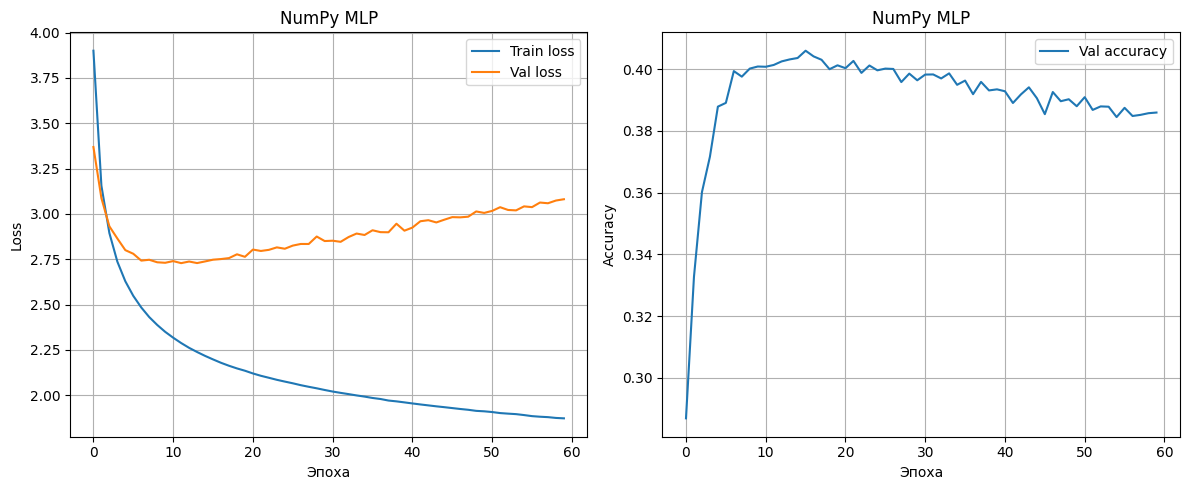

In [ ]:
plt.figure(
    figsize=(12, 5)
)

plt.subplot(
    1,
    2,
    1
)

plt.plot(
    numpy_train_loss,
    label="Train loss"
)

plt.plot(
    numpy_val_loss,
    label="Val loss"
)

plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("NumPy MLP")
plt.legend()
plt.grid(True)


plt.subplot(
    1,
    2,
    2
)

plt.plot(
    numpy_val_acc_history,
    label="Val accuracy"
)

plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("NumPy MLP")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 4. Реализация MLP на PyTorch

In [ ]:
class QuickDrawDataset(
    Dataset
):
    def __init__(
        self,
        X,
        y
    ):
        self.X = X
        self.y = y

    def __len__(self):
        return len(
            self.X
        )

    def __getitem__(
        self,
        idx
    ):
        image = torch.tensor(
            self.X[idx],
            dtype=torch.float32
        )

        label = torch.tensor(
            self.y[idx],
            dtype=torch.long
        )

        return (
            image,
            label
        )

In [ ]:
train_dataset = QuickDrawDataset(
    X_train,
    y_train
)

val_dataset = QuickDrawDataset(
    X_val,
    y_val
)

test_dataset = QuickDrawDataset(
    X_test,
    y_test
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

images, labels = next(
    iter(train_loader)
)

print(
    images.shape,
    labels.shape
)

torch.Size([128, 32, 32]) torch.Size([128])


In [ ]:
class TorchMLP(nn.Module):
    def __init__(
        self,
        layer_sizes,
        activation="relu",
        init_method="xavier"
    ):
        super().__init__()

        self.layer_sizes = layer_sizes
        self.activation = activation
        self.init_method = init_method

        if activation == "relu":
            activation_1 = nn.ReLU()
            activation_2 = nn.ReLU()

        elif activation == "tanh":
            activation_1 = nn.Tanh()
            activation_2 = nn.Tanh()

        else:
            raise ValueError(
                activation
            )

        self.net = nn.Sequential(
            nn.Flatten(),

            nn.Linear(
                layer_sizes[0],
                layer_sizes[1]
            ),

            activation_1,

            nn.Linear(
                layer_sizes[1],
                layer_sizes[2]
            ),

            activation_2,

            nn.Linear(
                layer_sizes[2],
                layer_sizes[3]
            )
        )

        for layer in self.net:
            if isinstance(
                layer,
                nn.Linear
            ):
                if init_method == "xavier":
                    nn.init.xavier_uniform_(
                        layer.weight
                    )

                elif init_method == "he":
                    nn.init.kaiming_normal_(
                        layer.weight,
                        nonlinearity="relu"
                    )

                else:
                    raise ValueError(
                        init_method
                    )

                layer.bias.data.zero_()

    def forward(self, x):
        return self.net(x)

In [ ]:
def evaluate_torch(
    model,
    loader,
    criterion
):
    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            outputs = model(
                images
            )

            loss = criterion(
                outputs,
                labels
            )

            running_loss += (
                loss.item()
            )

            predicted = torch.argmax(
                outputs,
                dim=1
            )

            total += (
                labels.size(0)
            )

            correct += (
                predicted == labels
            ).sum().item()

    loss = (
        running_loss
        / len(loader)
    )

    accuracy = (
        correct / total
    )

    return (
        loss,
        accuracy
    )

In [ ]:
def train_torch(
    model,
    train_loader,
    val_loader,
    epochs=60,
    lr=0.001,
    model_path="./models/best_torch_model.pth"
):
    criterion = (
        nn.CrossEntropyLoss()
    )

    optimizer = optim.Adam(
        model.parameters(),
        lr=lr
    )

    train_losses = []
    val_losses = []
    val_accuracies = []
    epoch_times = []

    best_val_acc = 0
    best_epoch = 0

    for epoch in range(
        epochs
    ):
        start_time = (
            time.time()
        )

        model.train()

        running_loss = 0

        for images, labels in train_loader:
            optimizer.zero_grad()

            outputs = model(
                images
            )

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()

            optimizer.step()

            running_loss += (
                loss.item()
            )

        train_loss = (
            running_loss
            / len(train_loader)
        )

        val_loss, val_acc = (
            evaluate_torch(
                model,
                val_loader,
                criterion
            )
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1

            torch.save(
                model.state_dict(),
                model_path
            )

        epoch_time = (
            time.time()
            - start_time
        )

        train_losses.append(
            train_loss
        )

        val_losses.append(
            val_loss
        )

        val_accuracies.append(
            val_acc
        )

        epoch_times.append(
            epoch_time
        )

        print(
            f"Epoch {epoch + 1}/{epochs}: "
            f"val_loss={val_loss:.4f}, "
            f"val_acc={val_acc:.4f}, "
            f"time={epoch_time:.2f}s"
        )

    model.load_state_dict(
        torch.load(
            model_path,
            weights_only=True
        )
    )

    model.eval()

    return (
        train_losses,
        val_losses,
        val_accuracies,
        epoch_times,
        best_epoch,
        best_val_acc
    )

In [ ]:
torch.manual_seed(SEED)

torch_model = TorchMLP(
    layer_sizes,
    activation="relu",
    init_method="xavier"
)

torch_train_loss, torch_val_loss, torch_val_acc_history, torch_epoch_time, torch_best_epoch, torch_best_val_acc = train_torch(
    torch_model,
    train_loader,
    val_loader,
    epochs=60,
    lr=0.001,
    model_path="./models/best_torch_model.pth"
)

criterion = (
    nn.CrossEntropyLoss()
)

torch_val_loss_best, torch_val_acc = evaluate_torch(
    torch_model,
    val_loader,
    criterion
)

torch_test_loss, torch_test_acc = evaluate_torch(
    torch_model,
    test_loader,
    criterion
)

torch.save(
    torch_model,
    "./models/full_model.pth"
)

torch_model_loaded = torch.load(
    "./models/full_model.pth",
    weights_only=False
)

torch_model_loaded.eval()

print(
    "Best epoch:",
    torch_best_epoch
)

print(
    "Val accuracy:",
    torch_val_acc
)

print(
    "Test accuracy:",
    torch_test_acc
)

Epoch 1/60: val_loss=3.3883, val_acc=0.2823, time=9.72s
Epoch 2/60: val_loss=3.0611, val_acc=0.3371, time=9.92s
Epoch 3/60: val_loss=2.9143, val_acc=0.3632, time=9.90s
Epoch 4/60: val_loss=2.8448, val_acc=0.3750, time=9.83s
Epoch 5/60: val_loss=2.7963, val_acc=0.3818, time=9.76s
Epoch 6/60: val_loss=2.7677, val_acc=0.3907, time=9.68s
Epoch 7/60: val_loss=2.7444, val_acc=0.3939, time=10.07s
Epoch 8/60: val_loss=2.7496, val_acc=0.3942, time=9.70s
Epoch 9/60: val_loss=2.7328, val_acc=0.3996, time=9.72s
Epoch 10/60: val_loss=2.7521, val_acc=0.3968, time=9.55s
Epoch 11/60: val_loss=2.7241, val_acc=0.4038, time=9.84s
Epoch 12/60: val_loss=2.7355, val_acc=0.4041, time=9.71s
Epoch 13/60: val_loss=2.7467, val_acc=0.4038, time=9.78s
Epoch 14/60: val_loss=2.7433, val_acc=0.4024, time=9.62s
Epoch 15/60: val_loss=2.7559, val_acc=0.4043, time=9.65s
Epoch 16/60: val_loss=2.7605, val_acc=0.4033, time=9.69s
Epoch 17/60: val_loss=2.7628, val_acc=0.4030, time=9.83s
Epoch 18/60: val_loss=2.7594, val_acc=0

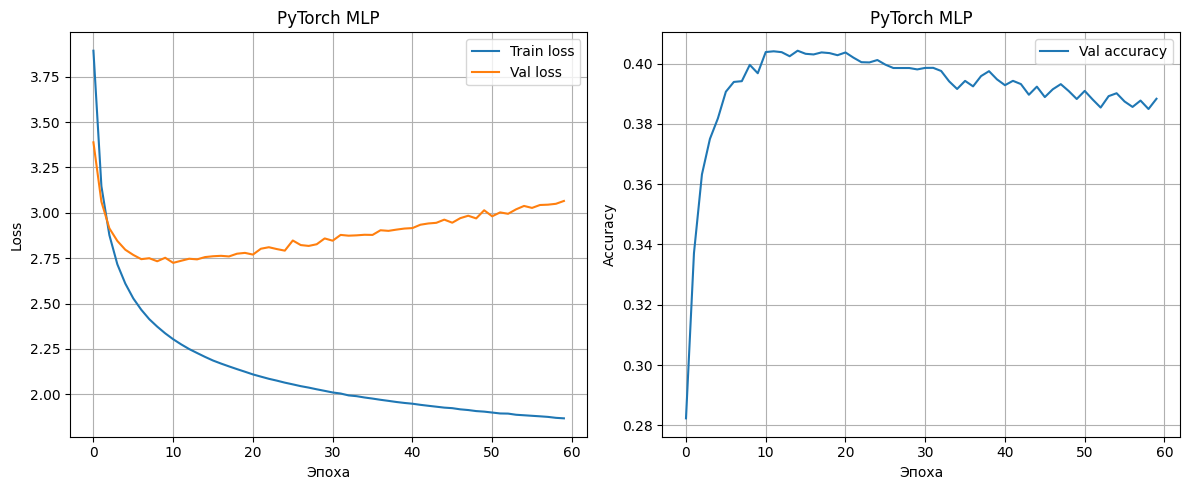

In [ ]:
plt.figure(
    figsize=(12, 5)
)

plt.subplot(
    1,
    2,
    1
)

plt.plot(
    torch_train_loss,
    label="Train loss"
)

plt.plot(
    torch_val_loss,
    label="Val loss"
)

plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("PyTorch MLP")
plt.legend()
plt.grid(True)


plt.subplot(
    1,
    2,
    2
)

plt.plot(
    torch_val_acc_history,
    label="Val accuracy"
)

plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("PyTorch MLP")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 5. Эксперименты и анализ

NumPy: val = 0.406 test = 0.4066 time = 1013.54
PyTorch: val = 0.4043 test = 0.405 time = 591.36


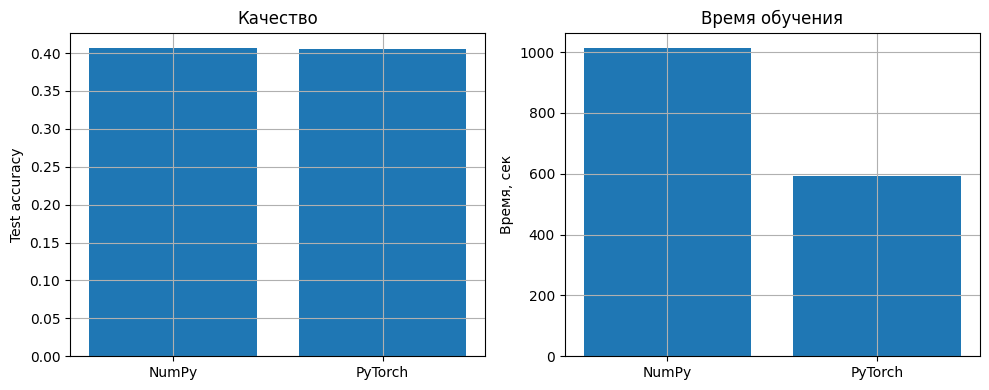

In [ ]:
numpy_time = sum(
    numpy_epoch_time
)

torch_time = sum(
    torch_epoch_time
)

print(
    "NumPy:",
    "val =", round(numpy_val_acc, 4),
    "test =", round(numpy_test_acc, 4),
    "time =", round(numpy_time, 2)
)

print(
    "PyTorch:",
    "val =", round(torch_val_acc, 4),
    "test =", round(torch_test_acc, 4),
    "time =", round(torch_time, 2)
)

plt.figure(
    figsize=(10, 4)
)

plt.subplot(
    1,
    2,
    1
)

plt.bar(
    ["NumPy", "PyTorch"],
    [numpy_test_acc, torch_test_acc]
)

plt.ylabel("Test accuracy")
plt.title("Качество")
plt.grid(True)


plt.subplot(
    1,
    2,
    2
)

plt.bar(
    ["NumPy", "PyTorch"],
    [numpy_time, torch_time]
)

plt.ylabel("Время, сек")
plt.title("Время обучения")
plt.grid(True)

plt.tight_layout()
plt.show()

### 5.1. ReLU vs Tanh

Epoch 1/20: val_loss=3.3883, val_acc=0.2823, time=9.58s
Epoch 2/20: val_loss=3.0611, val_acc=0.3371, time=9.69s
Epoch 3/20: val_loss=2.9143, val_acc=0.3632, time=9.72s
Epoch 4/20: val_loss=2.8448, val_acc=0.3750, time=9.71s
Epoch 5/20: val_loss=2.7963, val_acc=0.3818, time=9.61s
Epoch 6/20: val_loss=2.7677, val_acc=0.3907, time=9.68s
Epoch 7/20: val_loss=2.7444, val_acc=0.3939, time=9.52s
Epoch 8/20: val_loss=2.7496, val_acc=0.3942, time=9.53s
Epoch 9/20: val_loss=2.7328, val_acc=0.3996, time=9.61s
Epoch 10/20: val_loss=2.7521, val_acc=0.3968, time=9.48s
Epoch 11/20: val_loss=2.7241, val_acc=0.4038, time=9.90s
Epoch 12/20: val_loss=2.7355, val_acc=0.4041, time=9.63s
Epoch 13/20: val_loss=2.7467, val_acc=0.4038, time=9.59s
Epoch 14/20: val_loss=2.7433, val_acc=0.4024, time=9.51s
Epoch 15/20: val_loss=2.7559, val_acc=0.4043, time=9.51s
Epoch 16/20: val_loss=2.7605, val_acc=0.4033, time=9.57s
Epoch 17/20: val_loss=2.7628, val_acc=0.4030, time=9.70s
Epoch 18/20: val_loss=2.7594, val_acc=0.

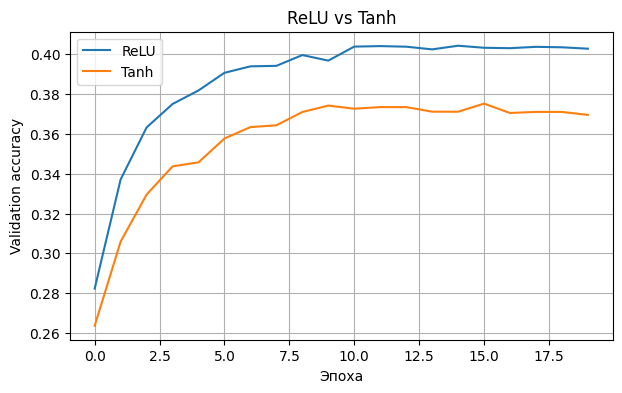

Best ReLU: 0.4042820428590752 epoch: 15
Best Tanh: 0.37520047921779287 epoch: 16
Вывод: в этом эксперименте ReLU показала более высокую validation accuracy.


In [ ]:
torch.manual_seed(SEED)

relu_model = TorchMLP(
    layer_sizes,
    activation="relu",
    init_method="xavier"
)

relu_train_loss, relu_val_loss, relu_val_acc, relu_epoch_time, relu_best_epoch, relu_best_val_acc = train_torch(
    relu_model,
    train_loader,
    val_loader,
    epochs=20,
    lr=0.001,
    model_path="./models/relu_experiment.pth"
)


torch.manual_seed(SEED)

tanh_model = TorchMLP(
    layer_sizes,
    activation="tanh",
    init_method="xavier"
)

tanh_train_loss, tanh_val_loss, tanh_val_acc, tanh_epoch_time, tanh_best_epoch, tanh_best_val_acc = train_torch(
    tanh_model,
    train_loader,
    val_loader,
    epochs=20,
    lr=0.001,
    model_path="./models/tanh_experiment.pth"
)

plt.figure(
    figsize=(7, 4)
)

plt.plot(
    relu_val_acc,
    label="ReLU"
)

plt.plot(
    tanh_val_acc,
    label="Tanh"
)

plt.xlabel("Эпоха")
plt.ylabel("Validation accuracy")
plt.title("ReLU vs Tanh")
plt.legend()
plt.grid(True)

plt.show()

print(
    "Best ReLU:",
    relu_best_val_acc,
    "epoch:",
    relu_best_epoch
)

print(
    "Best Tanh:",
    tanh_best_val_acc,
    "epoch:",
    tanh_best_epoch
)

if relu_best_val_acc > tanh_best_val_acc:
    print(
        "Вывод: в этом эксперименте ReLU показала более высокую validation accuracy."
    )
else:
    print(
        "Вывод: в этом эксперименте Tanh показала более высокую validation accuracy."
    )

## 6. Инференс и сравнение качества

In [ ]:
def predict_numpy(
    model,
    x
):
    x = x.reshape(
        1,
        -1
    )

    logits = model.forward(
        x
    )

    logits = (
        logits
        - np.max(
            logits,
            axis=1,
            keepdims=True
        )
    )

    exp_logits = np.exp(
        logits
    )

    probs = (
        exp_logits
        / np.sum(
            exp_logits,
            axis=1,
            keepdims=True
        )
    )

    predicted = np.argmax(
        probs,
        axis=1
    )[0]

    probability = probs[
        0,
        predicted
    ]

    return (
        predicted,
        probability
    )


def predict_torch(
    model,
    x
):
    model.eval()

    x = torch.tensor(
        x,
        dtype=torch.float32
    ).unsqueeze(0)

    with torch.no_grad():
        outputs = model(
            x
        )

        probs = torch.softmax(
            outputs,
            dim=1
        )

        predicted = torch.argmax(
            probs,
            dim=1
        ).item()

        probability = probs[
            0,
            predicted
        ].item()

    return (
        predicted,
        probability
    )

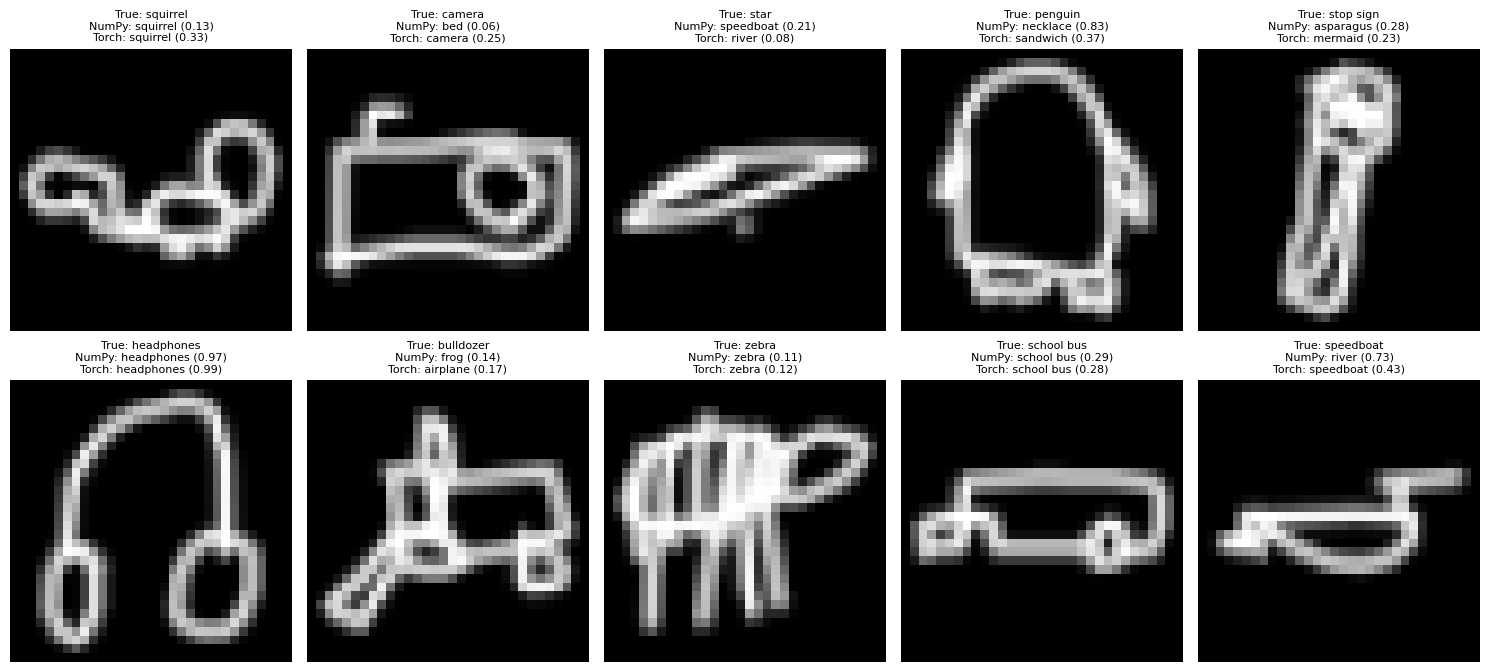

In [ ]:
plt.figure(
    figsize=(15, 7)
)

for i in range(10):
    true_label = int(
        y_test[i]
    )

    numpy_pred, numpy_prob = (
        predict_numpy(
            numpy_model_loaded,
            X_test[i]
        )
    )

    torch_pred, torch_prob = (
        predict_torch(
            torch_model_loaded,
            X_test[i]
        )
    )

    plt.subplot(
        2,
        5,
        i + 1
    )

    plt.imshow(
        X_test[i],
        cmap="gray"
    )

    plt.title(
        f"True: {class_names[true_label]}\n"
        f"NumPy: {class_names[numpy_pred]} ({numpy_prob:.2f})\n"
        f"Torch: {class_names[torch_pred]} ({torch_prob:.2f})",
        fontsize=8
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

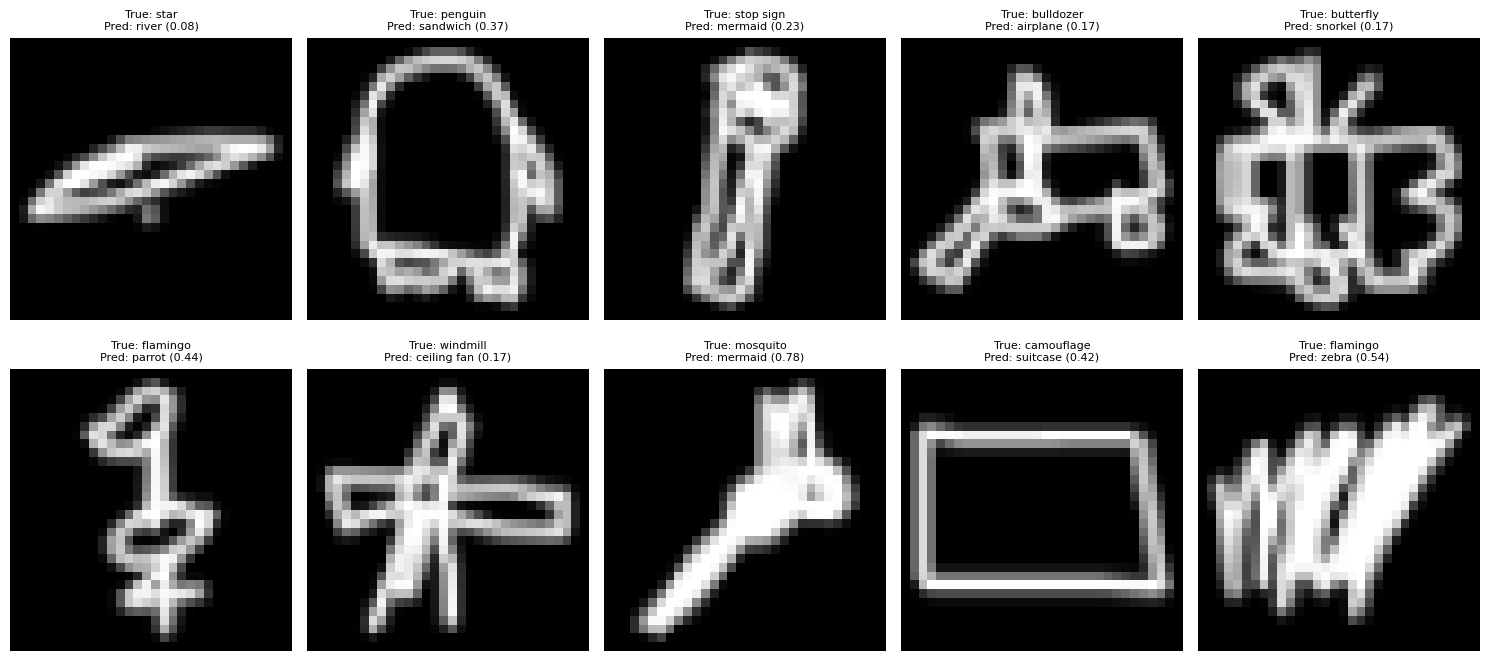

In [ ]:
errors = []

for i in range(
    len(X_test)
):
    pred, prob = predict_torch(
        torch_model_loaded,
        X_test[i]
    )

    if pred != int(
        y_test[i]
    ):
        errors.append(
            (
                i,
                pred,
                prob
            )
        )

    if len(errors) == 10:
        break

plt.figure(
    figsize=(15, 7)
)

for j, error in enumerate(
    errors
):
    idx, pred, prob = error
    true_label = int(
        y_test[idx]
    )

    plt.subplot(
        2,
        5,
        j + 1
    )

    plt.imshow(
        X_test[idx],
        cmap="gray"
    )

    plt.title(
        f"True: {class_names[true_label]}\n"
        f"Pred: {class_names[pred]} ({prob:.2f})",
        fontsize=8
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

**Анализ ошибок.** Модель чаще ошибается на похожих друг на друга рисунках и на изображениях, где объект нарисован слишком просто или не очень понятно. Так как MLP работает с изображением как с набором пикселей, ей сложнее различать классы с похожими формами и контурами. Кроме того, один и тот же объект разные люди могут рисовать очень по-разному, что тоже усложняет классификацию.

Во время обучения точность на validation сначала росла и была максимальной примерно на 15–18 эпохе, а потом начала снижаться. Это говорит о переобучении: модель всё лучше запоминала обучающие данные, но хуже работала на новых. Поэтому для итоговой оценки использовалась модель с лучшей validation accuracy.

### Три шага для улучшения

1. Подобрать число скрытых слоёв и нейронов по validation accuracy.
2. Подобрать learning rate и число эпох по validation loss/accuracy.
3. При переобучении использовать изученные L2-регуляризацию или Dropout.

## 7. Итог

В проекте реализованы и сравнены MLP на NumPy и PyTorch. Для выбора итогового состояния моделей использовалась validation accuracy, после чего качество оценивалось на тестовой выборке.

In [ ]:
print(
    "NumPy best epoch:",
    numpy_best_epoch
)

print(
    "NumPy val accuracy:",
    numpy_val_acc
)

print(
    "NumPy test accuracy:",
    numpy_test_acc
)

print()

print(
    "PyTorch best epoch:",
    torch_best_epoch
)

print(
    "PyTorch val accuracy:",
    torch_val_acc
)

print(
    "PyTorch test accuracy:",
    torch_test_acc
)

print()

print(
    "NumPy val >= 0.40:",
    numpy_val_acc >= 0.40
)

print(
    "NumPy test >= 0.40:",
    numpy_test_acc >= 0.40
)

print(
    "PyTorch val >= 0.40:",
    torch_val_acc >= 0.40
)

print(
    "PyTorch test >= 0.40:",
    torch_test_acc >= 0.40
)

NumPy best epoch: 16
NumPy val accuracy: 0.4060018163900215
NumPy test accuracy: 0.4066473429951691

PyTorch best epoch: 15
PyTorch val accuracy: 0.4042820428590752
PyTorch test accuracy: 0.40498550724637683

NumPy val >= 0.40: True
NumPy test >= 0.40: True
PyTorch val >= 0.40: True
PyTorch test >= 0.40: True


In [ ]:
print("NumPy val accuracy:", numpy_val_acc)
print("NumPy test accuracy:", numpy_test_acc)

print("PyTorch val accuracy:", torch_val_acc)
print("PyTorch test accuracy:", torch_test_acc)

NumPy val accuracy: 0.4060018163900215
NumPy test accuracy: 0.4066473429951691
PyTorch val accuracy: 0.4042820428590752
PyTorch test accuracy: 0.40498550724637683
